# 01 - Data Understanding

## Price Intelligence Platform

Ce notebook correspond a la premiere phase du travail Data Analyst : comprendre les donnees disponibles avant le nettoyage et les tests statistiques.

**Objectif :** analyser la structure du dataset, la couverture des plateformes/catégories, les valeurs manquantes, la distribution des prix et les premiers outliers.


## Source officielle mise à jour

Après le dernier merge, la source officielle des données est BigQuery :

```text
price-intelligence-495411.price_intelligence.products
```

Le notebook charge BigQuery en priorité. Si l'accès BigQuery n'est pas disponible dans Anaconda, il utilise un snapshot CSV exporté dans `outputs/raw_data/bigquery_products_export.csv`. Le fallback local JSON ne doit servir qu'au développement offline.


## BigQuery obligatoire

Ce notebook ne doit plus utiliser les anciens JSON locaux. La source officielle est BigQuery :

```text
price-intelligence-495411.price_intelligence.products
```

Si BigQuery n’est pas accessible depuis Anaconda, exporte la table BigQuery en CSV et place le fichier ici :

```text
C:\Users\Admin\Desktop\data-analysis\outputs\raw_data\bigquery_products_export.csv
```

Le notebook utilisera ce snapshot BigQuery. Sans accès BigQuery et sans export CSV, il s’arrêtera au lieu de reprendre les anciennes données locales.


## 1. Contexte du projet

Le projet est une plateforme de veille tarifaire e-commerce. Les données sont collectées depuis plusieurs plateformes, puis stockées et préparées pour l'analyse.

Architecture globale :

```text
Scraping -> Bigtable -> BigQuery / dbt -> Python Analytics -> Dashboard / Rapport
```

Dans ce notebook, on ne nettoie pas encore les données. On observe et on documente les problèmes à traiter dans la phase suivante.

## 2. Imports et configuration

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def find_data_analysis_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    candidates += [candidate / "data-analysis" for candidate in candidates]
    for candidate in candidates:
        if (candidate / "price_analysis.py").exists() and (candidate / "notebooks").exists():
            return candidate.resolve()
    raise FileNotFoundError("Impossible de trouver le dossier data-analysis. Ouvre le notebook depuis data-analysis ou depuis le repo price-intelligence.")

DATA_ANALYSIS_DIR = find_data_analysis_root()
PROJECT_ROOT = DATA_ANALYSIS_DIR.parent

if str(DATA_ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(DATA_ANALYSIS_DIR))

import price_analysis as pa

sns.set_theme(style="whitegrid")

print("Dossier de travail Data Analysis :", DATA_ANALYSIS_DIR)
print("Dossier source du projet :", PROJECT_ROOT)


Dossier de travail Data Analysis : C:\Users\Admin\Desktop\price-intelligence\data-analysis
Dossier source du projet : C:\Users\Admin\Desktop\price-intelligence


## 3. Configuration de l'auto-sauvegarde

In [2]:
OUTPUTS_DIR = DATA_ANALYSIS_DIR / "outputs"
OUTPUT_TABLES = OUTPUTS_DIR / "tables"
OUTPUT_FIGURES = OUTPUTS_DIR / "figures"

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

AUTO_SAVE = True

print("Auto-sauvegarde activée :", AUTO_SAVE)
print("Dossier des tableaux :", OUTPUT_TABLES)
print("Dossier des graphiques :", OUTPUT_FIGURES)

Auto-sauvegarde activée : True
Dossier des tableaux : C:\Users\Admin\Desktop\price-intelligence\data-analysis\outputs\tables
Dossier des graphiques : C:\Users\Admin\Desktop\price-intelligence\data-analysis\outputs\figures


In [3]:

EXPECTED_MIN_RAW_ROWS = 20000
EXPECTED_STORE = "sport-direct"
EXPECTED_MAX_NULL_PRICE = 500

def assert_official_bigquery_data(raw_df, cleaned_df=None, source=None):
    stores = set(raw_df.get("store", pd.Series(dtype="object")).dropna().astype(str).str.lower())
    null_price = raw_df["current_price"].isna().sum() if "current_price" in raw_df.columns else None
    if source is not None and source != "bigquery_live":
        raise ValueError(f"Source invalide: {source}. Le notebook doit utiliser BigQuery live, pas un ancien export/local.")
    if len(raw_df) < EXPECTED_MIN_RAW_ROWS:
        raise ValueError(f"Dataset trop petit ({len(raw_df)} lignes). Anciennes donnees detectees: recharge depuis BigQuery live.")
    if EXPECTED_STORE not in stores:
        raise ValueError(f"Store {EXPECTED_STORE} absent. Anciennes donnees detectees ou notebook non relance depuis BigQuery.")
    if null_price is not None and null_price > EXPECTED_MAX_NULL_PRICE:
        raise ValueError(f"Trop de prix null ({null_price}). Verifie la table BigQuery source.")
    if cleaned_df is not None and len(cleaned_df) < 15000:
        raise ValueError(f"Dataset nettoye trop petit ({len(cleaned_df)} lignes). Relance 02_data_cleaning.ipynb avec BigQuery live.")


## 4. Chargement des données

On charge les fichiers JSON locaux du projet `price-intelligence`. Plus tard, la même logique pourra être reliée à BigQuery.

In [4]:
# Securite : BigQuery live obligatoire pour eviter les anciennes donnees
DATA_SOURCE = "bigquery"
BQ_TABLE = "price-intelligence-495411.price_intelligence.products"
RAW_EXPORT_PATH = DATA_ANALYSIS_DIR / "outputs" / "raw_data" / "bigquery_products_export.csv"

raw_rows, effective_source = pa.load_project_rows(
    source=DATA_SOURCE,
    table_id=BQ_TABLE,
    project_root=PROJECT_ROOT,
    export_path=RAW_EXPORT_PATH,
    allow_export_fallback=False,
    allow_local_fallback=False,
)
raw_df = pd.DataFrame(raw_rows)
rows = pa.normalize_rows(raw_rows)
df = pd.DataFrame(rows)

assert_official_bigquery_data(raw_df, df, effective_source)

print("Source utilisee :", effective_source)
print("Table BigQuery officielle :", BQ_TABLE)
print("Nombre total de lignes brutes chargees :", len(raw_rows))
print("Nombre de lignes valides apres validation du prix :", len(df))
print("Lignes brutes avec name null :", raw_df["name"].isna().sum() if "name" in raw_df.columns else "colonne absente")
print("Lignes brutes avec current_price null :", raw_df["current_price"].isna().sum() if "current_price" in raw_df.columns else "colonne absente")
print("Plateformes detectees :", sorted(raw_df["store"].dropna().astype(str).str.lower().unique()) if "store" in raw_df.columns else "colonne absente")

df.head()


Source utilisee : bigquery_live
Table BigQuery officielle : price-intelligence-495411.price_intelligence.products
Nombre total de lignes brutes chargees : 30517
Nombre de lignes valides apres validation du prix : 30325
Lignes brutes avec name null : 192
Lignes brutes avec current_price null : 192
Plateformes detectees : ['ebay', 'jumia', 'sport-direct', 'unknown']


,store,category,name,price,price_before_discount,discount,stars,availability,scraped_at
0,ebay,racket-sports,"2Pcs WILSON Pink Tennis Balls, High Elastic Tr...",601.99,NaN,NaN,0.0,In Stock,2026-05-23T13:07:39.573902
1,ebay,racket-sports,Championship Extra-Duty XD Official Tennis Bal...,724.18,NaN,NaN,0.0,In Stock,2026-05-23T13:07:39.494971
2,ebay,racket-sports,86 Tennis Balls 4 Wilson 3 Pack Cases Are Seal...,647.41,NaN,NaN,0.0,In Stock,2026-05-23T13:07:39.619165
3,ebay,racket-sports,Tretorn Micro X Pressureless Tennis Balls Doze...,421.89,NaN,NaN,0.0,In Stock,2026-05-23T13:07:39.427997
4,ebay,racket-sports,Wilson Blade Pro 100 v10 in 43/8 Opens in a ne...,2141.38,NaN,NaN,0.0,In Stock,2026-05-23T13:08:09.387908


## 5. Dimensions et colonnes du dataset

In [5]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre de lignes : 30325
Nombre de colonnes : 9


In [6]:
print("Colonnes disponibles :")
df.columns.tolist()

Colonnes disponibles :


['store',
 'category',
 'name',
 'price',
 'price_before_discount',
 'discount',
 'stars',
 'availability',
 'scraped_at']

## 6. Types des données et aperçu

In [7]:
print("Informations sur les types de données :")
df.info()

Informations sur les types de données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30325 entries, 0 to 30324
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   store                  30325 non-null  object 
 1   category               30325 non-null  object 
 2   name                   30325 non-null  object 
 3   price                  30325 non-null  float64
 4   price_before_discount  9243 non-null   float64
 5   discount               9243 non-null   float64
 6   stars                  30325 non-null  float64
 7   availability           30325 non-null  object 
 8   scraped_at             30325 non-null  object 
dtypes: float64(4), object(5)
memory usage: 2.1+ MB


In [8]:
print("Aperçu aléatoire de 10 produits :")
df.sample(10, random_state=42)

Aperçu aléatoire de 10 produits :


,store,category,name,price,price_before_discount,discount,stars,availability,scraped_at
13355,ebay,combat-sports,"Boxing Hand Wraps by RDX, Inner, Boxing Wrist ...",203.41,NaN,NaN,0.0,In Stock,2026-05-17T15:12:32.929170
11408,ebay,unknown,100% Authentic SS18 Sealed Brand New SUPREME W...,439.28,NaN,NaN,0.0,In Stock,2026-05-17T15:14:54.983009
3518,ebay,gym,Nutricost Creatine + Energy 30 Servings (Peach...,184.81,NaN,NaN,0.0,In Stock,2026-05-22T13:40:00.309407
7090,sport-direct,gym,Whey Hey Elite Vanilla 1 kg,374.88,NaN,NaN,0.0,In Stock,2026-05-21T14:56:24.625331
8863,ebay,combat-sports,Athletics Shin Pads MMA Leg Guards Muay Thai K...,86.12,NaN,NaN,0.0,In Stock,2026-05-18T19:58:39.417259
9161,ebay,gym,"L-Methyl Folate 15mg,60 ml Liquid Drops -Suppl...",138.10,NaN,NaN,0.0,In Stock,2026-05-15T22:09:08.925780
10495,ebay,combat-sports,Boxing Head Guard Rubber Padded Training Sparr...,184.91,NaN,NaN,0.0,In Stock,2026-05-18T19:57:40.985940
11911,ebay,combat-sports,Buffalo Dental 62700 Mouthguard Material Clear...,374.90,NaN,NaN,0.0,In Stock,2026-05-16T13:13:29.107966
21478,jumia,racket-sports,Créatif Porte-clés Balle de Tennis Peluche Bal...,24.99,50.0,50.0,0.0,-,2026-05-15T22:00:01.752735
22218,jumia,basketball,"lacet Chaussures_Sport, basket-ball en toile",49.00,59.0,17.0,0.0,-,2026-05-18T19:50:52.436743


In [9]:
print("Résumé descriptif des données :")
df.describe(include="all").T

Résumé descriptif des données :


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
store,30325,3,ebay,16892,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,30325,7,combat-sports,7456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,30325,4530,Mercurial Lite Shin Guards,93,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,30325.0,NaN,NaN,NaN,489.971588,783.897421,6.66,134.12,274.88,562.5,35612.5
price_before_discount,9243.0,NaN,NaN,NaN,465.83232,456.080243,35.0,189.0,303.39,571.43,3000.0
discount,9243.0,NaN,NaN,NaN,37.046522,17.481644,1.0,25.0,36.0,49.0,90.0
stars,30325.0,NaN,NaN,NaN,0.498203,1.376396,0.0,0.0,0.0,0.0,5.0
availability,30325,2,In Stock,21954,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scraped_at,30325,20189,2026-05-16T13:07:58.689009,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Analyse des valeurs manquantes

In [10]:
missing = df.isna().sum().reset_index()
missing.columns = ["colonne", "nombre_valeurs_manquantes"]
missing["taux_valeurs_manquantes"] = missing["nombre_valeurs_manquantes"] / len(df)

print("Valeurs manquantes par colonne :")
missing.sort_values("taux_valeurs_manquantes", ascending=False)

Valeurs manquantes par colonne :


,colonne,nombre_valeurs_manquantes,taux_valeurs_manquantes
4,price_before_discount,21082,0.695202
5,discount,21082,0.695202
0,store,0,0.000000
2,name,0,0.000000
1,category,0,0.000000
3,price,0,0.000000
6,stars,0,0.000000
7,availability,0,0.000000
8,scraped_at,0,0.000000


## 8. Couverture par plateforme

In [11]:
store_counts = df["store"].value_counts().reset_index()
store_counts.columns = ["plateforme", "nombre_produits"]

print("Nombre de produits par plateforme :")
store_counts

Nombre de produits par plateforme :


,plateforme,nombre_produits
0,ebay,16892
1,jumia,8371
2,sport-direct,5062


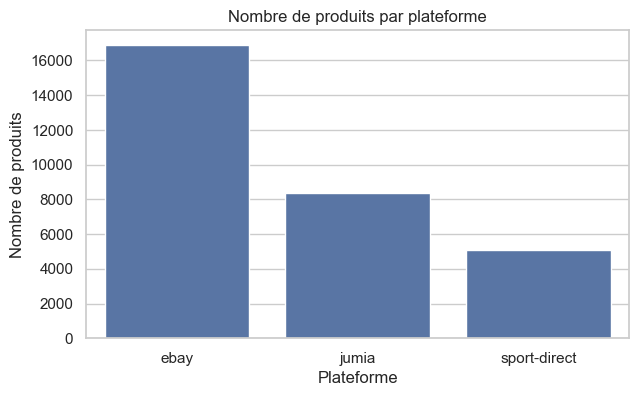

In [12]:
plt.figure(figsize=(7, 4))
sns.barplot(data=store_counts, x="plateforme", y="nombre_produits")
plt.title("Nombre de produits par plateforme")
plt.xlabel("Plateforme")
plt.ylabel("Nombre de produits")

if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "01_nombre_produits_par_plateforme.png", dpi=150, bbox_inches="tight")

plt.show()

## 9. Couverture par catégorie

In [13]:
category_counts = df["category"].value_counts().reset_index()
category_counts.columns = ["categorie", "nombre_produits"]

print("Nombre de produits par catégorie :")
category_counts

Nombre de produits par catégorie :


,categorie,nombre_produits
0,combat-sports,7456
1,football,5842
2,gym,4638
3,basketball,4029
4,unknown,3210
5,volleyball,2659
6,racket-sports,2491


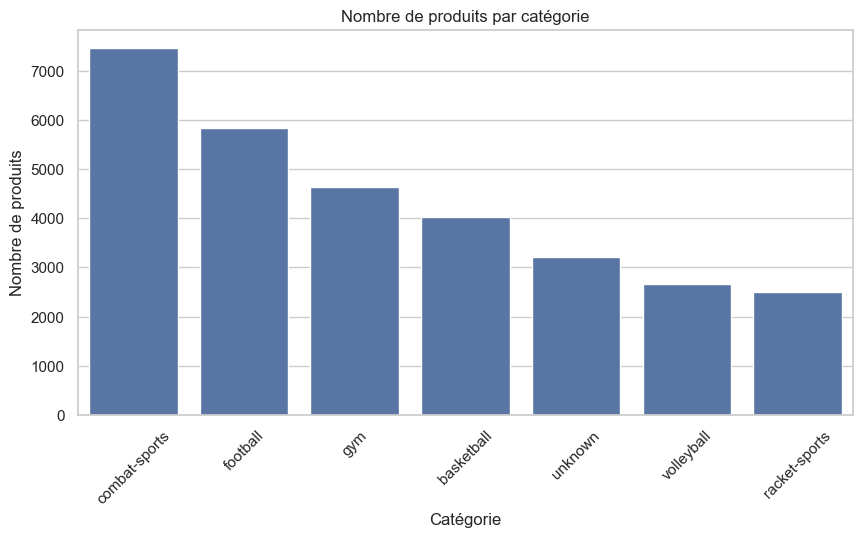

In [14]:
plt.figure(figsize=(10, 5))
sns.barplot(data=category_counts, x="categorie", y="nombre_produits")
plt.title("Nombre de produits par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de produits")
plt.xticks(rotation=45)

if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "01_nombre_produits_par_categorie.png", dpi=150, bbox_inches="tight")

plt.show()

## 10. Compréhension initiale des prix

In [15]:
print("Résumé statistique de la variable prix :")
df["price"].describe()

Résumé statistique de la variable prix :


count    30325.000000
mean       489.971588
std        783.897421
min          6.660000
25%        134.120000
50%        274.880000
75%        562.500000
max      35612.500000
Name: price, dtype: float64

In [16]:
price_by_store = df.groupby("store")["price"].agg(
    nombre_produits="count",
    prix_moyen="mean",
    prix_median="median",
    prix_minimum="min",
    prix_maximum="max",
    ecart_type="std"
).reset_index()

price_by_store = price_by_store.rename(columns={"store": "plateforme"})

print("Statistiques des prix par plateforme :")
price_by_store

Statistiques des prix par plateforme :


,plateforme,nombre_produits,prix_moyen,prix_median,prix_minimum,prix_maximum,ecart_type
0,ebay,16892,635.383722,356.03,6.66,35612.5,982.595111
1,jumia,8371,234.371632,178.99,9.00,1591.0,226.861233
2,sport-direct,5062,427.412414,287.38,31.25,5250.0,438.053667


In [17]:
price_by_category = df.groupby("category")["price"].agg(
    nombre_produits="count",
    prix_moyen="mean",
    prix_median="median",
    prix_minimum="min",
    prix_maximum="max",
    ecart_type="std"
).reset_index()

price_by_category = price_by_category.rename(columns={"category": "categorie"})

print("Statistiques des prix par catégorie :")
price_by_category

Statistiques des prix par catégorie :


,categorie,nombre_produits,prix_moyen,prix_median,prix_minimum,prix_maximum,ecart_type
0,basketball,4029,462.562224,227.00,9.16,17527.73,814.161331
1,combat-sports,7456,353.328152,199.00,9.00,6659.91,476.710985
2,football,5842,552.723655,312.38,9.16,9249.91,875.502235
3,gym,4638,352.798892,299.00,12.30,7862.50,344.025419
4,racket-sports,2491,745.503043,319.87,6.66,7347.37,946.234659
5,unknown,3210,699.273794,374.53,9.16,35612.50,1339.673378
6,volleyball,2659,523.994242,365.19,9.16,6012.41,511.801961


## 11. Produits les plus chers et premiers outliers

In [18]:
top_expensive = df.sort_values("price", ascending=False)[
    ["store", "category", "price", "name"]
].head(15)

top_expensive = top_expensive.rename(columns={
    "store": "plateforme",
    "category": "categorie",
    "price": "prix",
    "name": "nom_produit"
})

print("Top 15 des produits les plus chers :")
top_expensive

Top 15 des produits les plus chers :


,plateforme,categorie,prix,nom_produit
17318,ebay,unknown,35612.50,​1970/73 NY Knicks Championship Autographed Ba...
17319,ebay,unknown,35612.50,​1970/73 NY Knicks Championship Autographed Ba...
28757,ebay,basketball,17527.73,Size 10 - Jordan 1 Retro OG x Off-White High C...
28351,ebay,basketball,14032.25,DM7866-140 Travis Scott fragment design Nike A...
13203,ebay,unknown,11562.50,Nike Air Jordan 1 Low OG SP Travis Scott Rever...
13204,ebay,unknown,11562.50,Nike Air Jordan 1 Low OG SP Travis Scott Rever...
7563,ebay,football,9249.91,Nike Tiempo Legend VI 6 Elite Totti x Roma Gol...
8776,ebay,basketball,9249.91,NBA Victor Wembenyama Autographed Basketball W...
11618,ebay,basketball,8325.00,Tyrese Haliburton Signed & Multi-Inscribed Wil...
2856,ebay,basketball,8315.75,Size 13 - Jordan 1 Retro Low OG SP x Travis Sc...


## 12. Remises, notes et disponibilité

In [19]:
print("Résumé statistique des remises :")
df["discount"].describe()

Résumé statistique des remises :


count    9243.000000
mean       37.046522
std        17.481644
min         1.000000
25%        25.000000
50%        36.000000
75%        49.000000
max        90.000000
Name: discount, dtype: float64

In [20]:
top_discounts = df.dropna(subset=["discount"]).sort_values("discount", ascending=False)[
    ["store", "category", "discount", "price", "name"]
].head(10)

top_discounts = top_discounts.rename(columns={
    "store": "plateforme",
    "category": "categorie",
    "discount": "remise",
    "price": "prix",
    "name": "nom_produit"
})

print("Top 10 des plus grandes remises :")
top_discounts

Top 10 des plus grandes remises :


,plateforme,categorie,remise,prix,nom_produit
29105,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
20020,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
20026,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
20027,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
20025,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
20022,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
20028,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
20019,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
20017,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M
20018,jumia,combat-sports,90.0,49.0,Pakka COQUILLE PAKKA DE BOXE ROUGE M


In [21]:
print("Résumé statistique des notes clients :")
df["stars"].describe()

Résumé statistique des notes clients :


count    30325.000000
mean         0.498203
std          1.376396
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          5.000000
Name: stars, dtype: float64

In [22]:
print("Répartition des disponibilités :")
df["availability"].value_counts()

Répartition des disponibilités :


availability
In Stock    21954
-            8371
Name: count, dtype: int64

## 13. Sauvegarde automatique des outputs

In [23]:
if AUTO_SAVE:
    missing.to_csv(OUTPUT_TABLES / "01_valeurs_manquantes.csv", index=False)
    store_counts.to_csv(OUTPUT_TABLES / "01_nombre_produits_par_plateforme.csv", index=False)
    category_counts.to_csv(OUTPUT_TABLES / "01_nombre_produits_par_categorie.csv", index=False)
    price_by_store.to_csv(OUTPUT_TABLES / "01_prix_par_plateforme.csv", index=False)
    price_by_category.to_csv(OUTPUT_TABLES / "01_prix_par_categorie.csv", index=False)
    top_expensive.to_csv(OUTPUT_TABLES / "01_top_produits_plus_chers.csv", index=False)
    top_discounts.to_csv(OUTPUT_TABLES / "01_top_remises.csv", index=False)

    print("Auto-sauvegarde terminée.")
    print("Tableaux sauvegardés dans :", OUTPUT_TABLES)
    print("Graphiques sauvegardés dans :", OUTPUT_FIGURES)
else:
    print("Auto-sauvegarde désactivée.")

Auto-sauvegarde terminée.
Tableaux sauvegardés dans : C:\Users\Admin\Desktop\price-intelligence\data-analysis\outputs\tables
Graphiques sauvegardés dans : C:\Users\Admin\Desktop\price-intelligence\data-analysis\outputs\figures


## 15. Conclusion - Data Understanding

Premières observations à compléter après exécution du notebook :

- Le dataset contient des milliers de produits issus de plusieurs plateformes.
- Les plateformes disponibles sont eBay, Jumia et Walmart.
- Les catégories principales sont basketball, football, gym, combat-sports, volleyball et racket-sports.
- La colonne prix est exploitable après conversion numérique.
- Certaines colonnes comme les remises et les notes peuvent contenir des valeurs manquantes.
- La distribution des prix contient des outliers importants, surtout sur eBay.
- La médiane sera probablement plus fiable que la moyenne pour comparer les plateformes.
- La prochaine phase sera le nettoyage des données : valeurs manquantes, outliers, types et standardisation.